In [ ]:
# Bypass the Mac SSL certificate verification error
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
from sklearn.datasets import fetch_openml

# Fetching the Shuttle dataset from OpenML
print("Fetching dataset from OpenML... (this might take a few seconds)")
shuttle_data = fetch_openml(name='shuttle', version=1, as_frame=True, parser='auto')

#features (X), target labels (y)
X = shuttle_data.frame.drop('class', axis=1) 
y = shuttle_data.frame['class']              

print("Data successfully loaded!")
print(f"Dataset shape: {X.shape}")


Fetching dataset from OpenML... (this might take a few seconds)
Data successfully loaded!
Dataset shape: (58000, 9)


In [6]:
# 1. Check for missing values in our features
print("Missing values in each column:")
print(X.isnull().sum())

# 2. Check the distribution of our labels (how many of each class exist)
print("\nTarget label distribution:")
print(y.value_counts())


Missing values in each column:
A1    0
A2    0
A3    0
A4    0
A5    0
A6    0
A7    0
A8    0
A9    0
dtype: int64

Target label distribution:
class
1    45586
4     8903
5     3267
3      171
2       50
7       13
6       10
Name: count, dtype: int64


In [ ]:
#for cross checking our output 
# Create a new target label list (y_binary) , If the original class is '1', we keep it as 1 (Normal)
# #If it is anything else, we label it as -1 (Anomaly)
y_binary = y.apply(lambda val: 1 if val == '1' else -1)

print("Old labels:\n", y.value_counts().head(3)) # Showing just a few old ones
print("\nNew binary labels (1 = Normal, -1 = Anomaly):")
print(y_binary.value_counts())


Old labels:
 class
1    45586
4     8903
5     3267
Name: count, dtype: int64

New binary labels (1 = Normal, -1 = Anomaly):
class
 1    45586
-1    12414
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import IsolationForest

# 1. Create the Isolation Forest model
# 'contamination' = anamolous data
# here, 21% contamination
print("Building and training the Isolation Forest model...")
iso_forest = IsolationForest(
contamination =0.5,
max_samples = 256, 
random_state=42,
max_features = 1.0 , 
n_estimators = 100)

# Training the model ONLY on the raw features (X), hiding the answers
iso_forest.fit(X)

predictions = iso_forest.predict(X)

print("Model training and predictions complete!")

Building and training the Isolation Forest model...
Model training and predictions complete!


In [ ]:
from sklearn.preprocessing import StandardScaler

# applying scalar
print("Scaling the features...")
scaler = StandardScaler()

# Transform the raw data (X) into scaled data (X_scaled)
X_scaled = scaler.fit_transform(X)

# Run the model but with X_scaled
print("Running Experiment 3 (With Feature Scaling)...")
iso_scaled = IsolationForest(n_estimators=100, contamination=0.50, random_state=42)
iso_scaled.fit(X_scaled)

# Get predictions using the scaled data
predictions_scaled = iso_scaled.predict(X_scaled)

# Print the report
print("\nClassification Report (With Feature Scaling):")
print(classification_report(y_binary, predictions_scaled))

Scaling the features...
Running Experiment 3 (With Feature Scaling)...

Classification Report (With Feature Scaling):
              precision    recall  f1-score   support

          -1       0.40      0.94      0.56     12414
           1       0.97      0.62      0.76     45586

    accuracy                           0.69     58000
   macro avg       0.69      0.78      0.66     58000
weighted avg       0.85      0.69      0.71     58000



In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Define the grid of hyperparameter values you want to test
contaminations = [0.21, 0.30, 0.40, 0.50]
max_samples_list = [50, 100, 256]
n_estimators_list = [100, 200, 300]

# Create an empty list to store the results of each experiment
results_log = []

print("Starting automated Grid Search... This might take a moment.")

# 2. The Nested Loops: This will try every possible combination automatically
for cont in contaminations:
    for samples in max_samples_list:
        for trees in n_estimators_list:
            
            # Initialize the model with the current combination of dials
            model = IsolationForest(
                contamination=cont,
                max_samples=samples,
                n_estimators=trees,
                random_state=42
            )
            
            # Train and predict
            model.fit(X)
            preds = model.predict(X)
            
            # Automatically extract the exact scores for the Anomaly class (-1)
            # pos_label=-1 tells scikit-learn that -1 is our target success metric
            prec = precision_score(y_binary, preds, pos_label=-1)
            rec = recall_score(y_binary, preds, pos_label=-1)
            f1 = f1_score(y_binary, preds, pos_label=-1)
            
            # Save these results into a dictionary
            results_log.append({
                'Contamination': cont,
                'Max Samples': samples,
                'Trees (n_estimators)': trees,
                'Anomaly Precision': round(prec, 2),
                'Anomaly Recall': round(rec, 2),
                'Anomaly F1-Score': round(f1, 2)
            })

# summary table
df_results = pd.DataFrame(results_log)

# Sorting the table so the highest Recall scores are at the very top
df_results = df_results.sort_values(by='Anomaly Recall', ascending=False).reset_index(drop=True)

print("Grid Search Complete! Here are your results sorted by highest Recall:")
display(df_results)

Starting automated Grid Search... This might take a moment.
Grid Search Complete! Here are your results sorted by highest Recall:


,Contamination,Max Samples,Trees (n_estimators),Anomaly Precision,Anomaly Recall,Anomaly F1-Score
0,0.50,256,100,0.40,0.94,0.56
1,0.50,256,200,0.39,0.91,0.54
2,0.50,256,300,0.38,0.89,0.54
3,0.50,50,300,0.38,0.89,0.53
4,0.50,50,200,0.38,0.89,0.53
5,0.50,100,100,0.38,0.88,0.53
6,0.50,50,100,0.38,0.88,0.53
7,0.50,100,200,0.37,0.86,0.51
8,0.40,256,100,0.46,0.86,0.60
9,0.50,100,300,0.36,0.85,0.51


<Figure size 600x500 with 0 Axes>

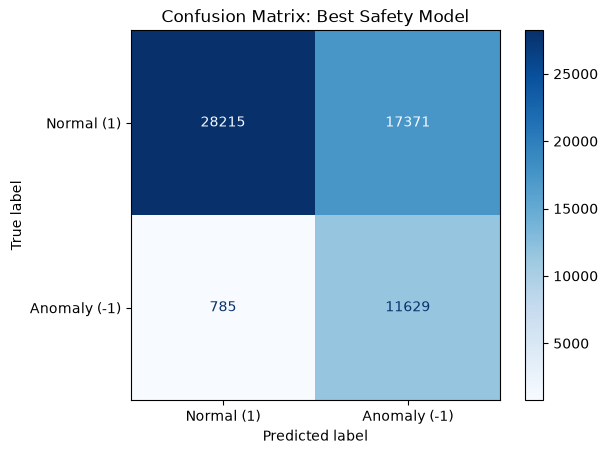

/var/folders/91/gp_cg6c55wngxsffgnqvhy_40000gn/T/ipykernel_5884/3998824268.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_results, x='Contamination', y='Anomaly Recall', marker='o', ci=None)


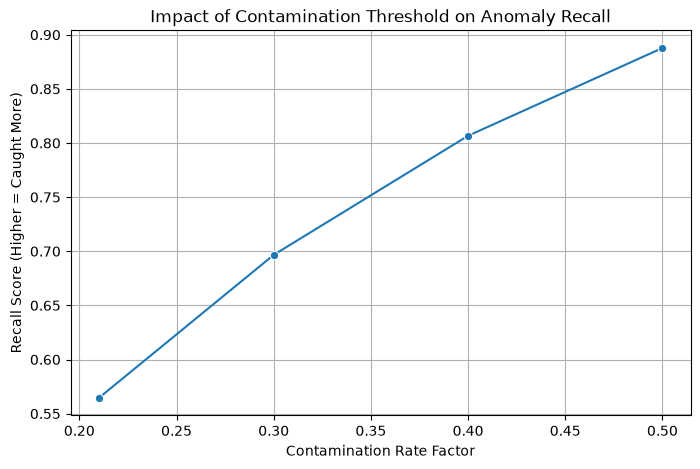

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = IsolationForest(contamination=0.5, max_samples=256, n_estimators=100, random_state=42)
best_model.fit(X)
best_preds = best_model.predict(X)

# --- PLOT 1: Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_binary, best_preds, labels=[1, -1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (1)', 'Anomaly (-1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Best Safety Model")
plt.savefig("confusion_matrix.png")
plt.show()

# --- PLOT 2: Hyperparameter Impact (Contamination vs Recall) ---
# This uses the df_results DataFrame from your automated grid search loop!
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_results, x='Contamination', y='Anomaly Recall', marker='o', ci=None)
plt.title("Impact of Contamination Threshold on Anomaly Recall")
plt.xlabel("Contamination Rate Factor")
plt.ylabel("Recall Score (Higher = Caught More)")
plt.grid(True)
plt.savefig("hyperparameter_impact.png") # Saves the image to your VS Code folder
plt.show()